## Raw Visualization
Inspect the raw DFTB energy surfaces and check Fourier-harmonic convergence to decide how many harmonics the anisotropic model needs.

Plot the raw 
- **$E(r)$** curves, 
- energy surfaces **$E_{min}(\chi, \psi)$**, **$E_{min}(\varphi_1, \varphi_2)$**
- and linecuts **$E_{min}(\chi)|\psi$**, **$E_{min}(\psi)|\chi$**, **$E_{min}(\varphi_2)|\chi$**, etc.

for the selected interaction (and a comparison across multiple interaction types).

---

### Data Exploration & Model Parameter Choice

In [2]:
import matplotlib.pyplot as plt

from chimorse.config import (
    FigureContext, get_colors, PLOT_PARAMS, MOLECULES
)
from chimorse.dataio import load_data
from chimorse.plotting import (
    plot_ER_raw_all, plot_ER, plot_ER_orientations,
    plot_energy_surfaces, plot_energy_surfaces_chi_psi,
    plot_energy_vs_chi_psi, plot_energy_vs_chi_psi_compact,
    plot_chi_psi_panel,
)

plt.rcParams.update(PLOT_PARAMS)

In [3]:
molecule_name = 'PA'
interaction = 'EP'
zero_zeta = True

molecule = MOLECULES[molecule_name]
R = 9

df_org = load_data(molecule, interaction, zero_zeta)
colors = get_colors()

ctx_org = FigureContext(base="Figures", molecule=molecule.name, data_type="org", interaction=interaction)

### Energy vs Distance E(r)

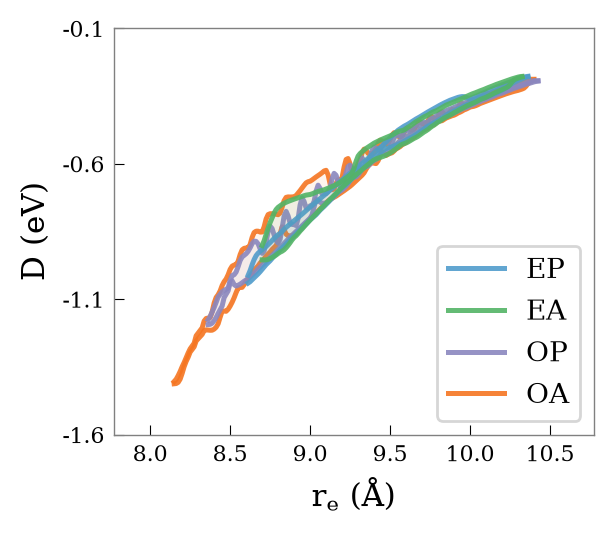

In [4]:
plot_ER_raw_all(molecule, zero_zeta)

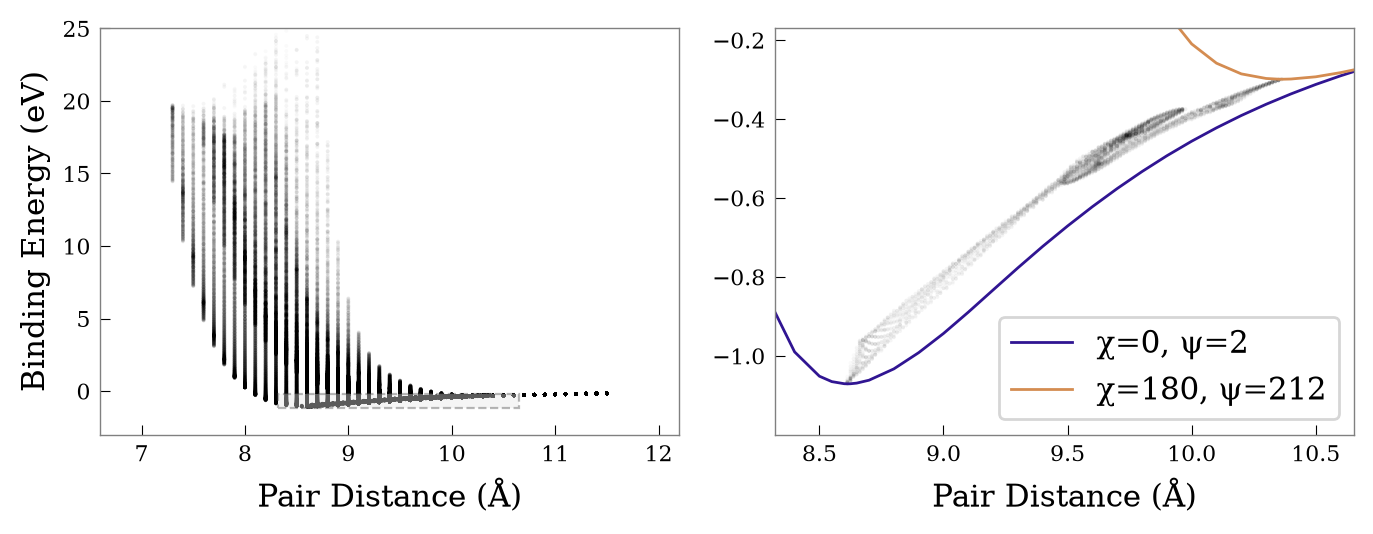

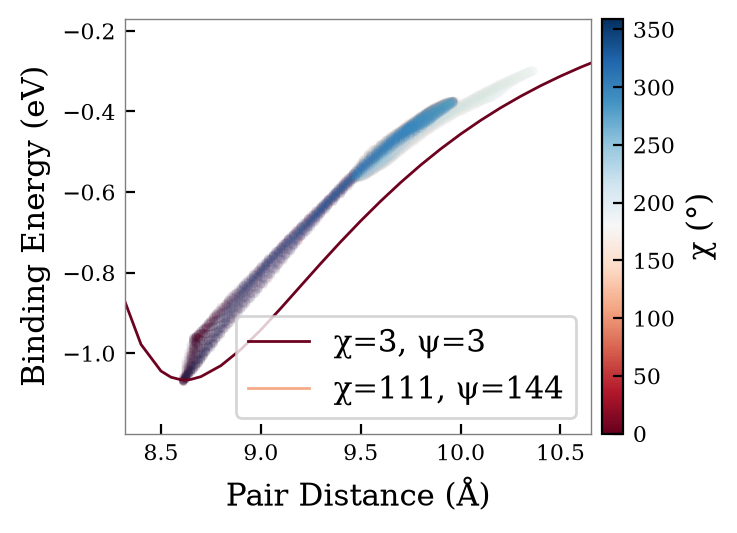

In [5]:
plot_ER(df_org, show_zoom_box=True, save_path=ctx_org.dir())
plot_ER_orientations(df_org, orientations=[(3,3), (111, 144)], color_by='chi', save_path=ctx_org.dir())

### Energy Surfaces

Energy surfaces:
- **$E_{min}(\varphi_1, \varphi_2)$** for fix distance and equilibrium distance
- **$E_{min}(\chi, \varphi)$** for fix distance and equilibrium distance
- **$E_{min}(\chi, \psi)$** for equilibrium distance

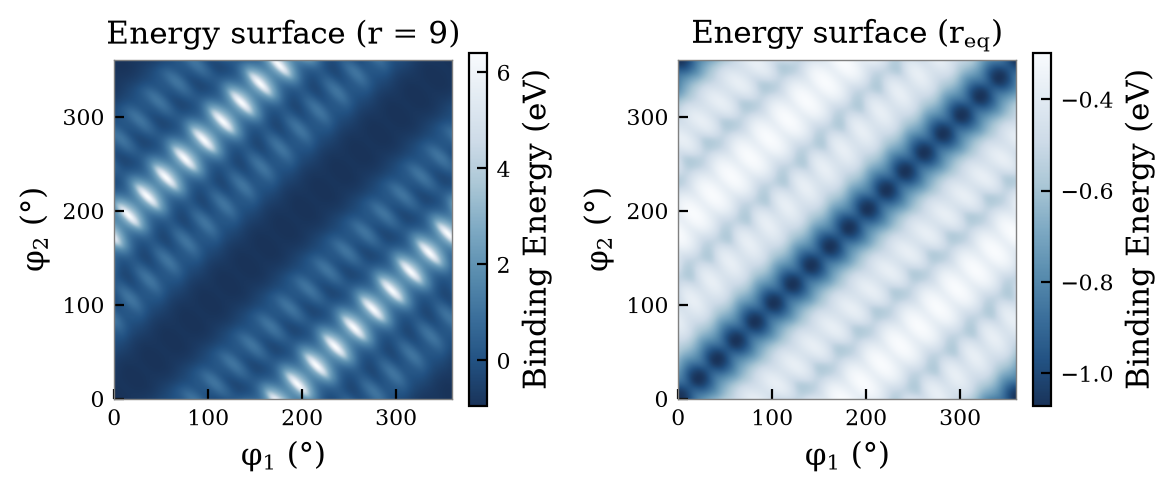

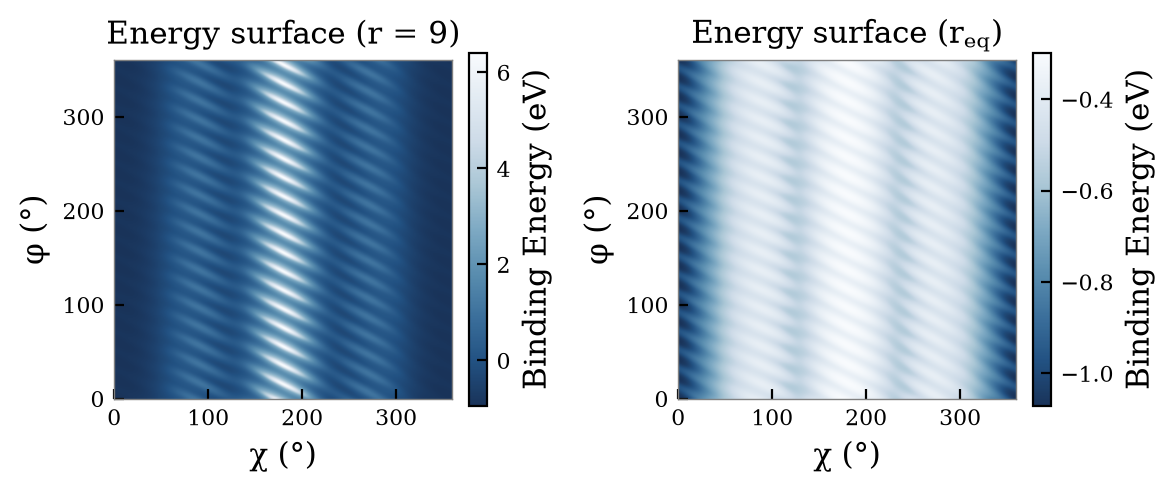

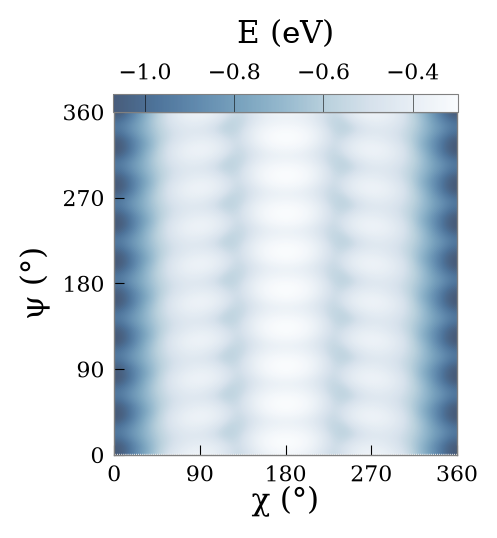

In [6]:
plot_energy_surfaces(df_org, screw_step=molecule.screw_step, fix_r=R, 
                     cmap=colors[interaction], mode='phi', save_path=ctx_org.dir())
plot_energy_surfaces(df_org, screw_step=molecule.screw_step, fix_r=R, 
                     cmap=colors[interaction], mode='chi', save_path=ctx_org.dir())
plot_energy_surfaces_chi_psi(df_org, interaction, molecule.screw_step, 
                             colors=colors, save_path=ctx_org.dir())

### Energy linecut scans

In [ ]:
plot_energy_vs_chi_psi(df_org,  screw_step=molecule.screw_step, x_axis='chi', 
                      n_cuts=12, cmap_name='PuOr', save_path=ctx_org.dir())
plot_energy_vs_chi_psi(df_org, x_axis='psi',  screw_step=molecule.screw_step,
                      n_cuts=5, cmap_name='twilight_shifted', save_path=ctx_org.dir())
plot_energy_vs_chi_psi_compact(df_org, interaction, molecule.screw_step, x_axis='chi', colors=colors,
                         cut_values=[0, 3, 9, 12], 
                         tol=0.25, save_path=ctx_org.dir())
plot_energy_vs_chi_psi_compact(df_org, interaction, molecule.screw_step, x_axis='psi', colors=colors,
                         cut_values=[0, 3, 9, 12], 
                         tol=0.25, save_path=ctx_org.dir())

In [ ]:
plot_chi_psi_panel(df_org, interaction,  molecule.screw_step,
                   colors = colors, left_label=True, save_path=ctx_org.dir())

### Comparison different interactions

In [ ]:
interaction_types = ['EP', 'EA', 'OP', 'OA']

for interaction in interaction_types:
    df_org = load_data(molecule, interaction, zero_zeta)
    left_label = True if interaction=='EP' else False
    plot_chi_psi_panel(df_org, interaction, molecule.screw_step, colors = colors, left_label=left_label)